<a href="https://colab.research.google.com/github/krishnakanthkona-3110/Interview_Prep/blob/main/Interview_Focused/Text_to_SQL_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://youtu.be/tiZCLoupYd0?si=SUmdou0VFDtnvogT


*   User Query
*   HyDE for query enhancement
*   Bi-encoder with HNSW for fast candidate retrieval (Embedding model :- BAAI/bge-base-en-v1.5)
*   Cross-encoder for precise reranking (Embedding model:- ColBERT-v2)

HyDE: The hypothetical document uses technical terminology and formal structure similar to actual documentation. When embedded by the bi-encoder, it produces a vector much closer to real documentation vectors, leading to better retrieval.

Persona Design for Our Text2SQL Agent

| Pillar | Our Agent |
|--------|-----------|
| **Role** | Senior SQL Developer and Data Analyst |
| **Tone** | Precise, technical, concise — no filler or speculation |
| **Boundaries** | **Can:** list tables, read schemas, generate & run SELECT queries · **Cannot:** modify data (no DELETE/DROP/UPDATE/INSERT), answer non-database questions, guess table or column names |
| **Output format** | Always show: (1) the SQL query generated, (2) the query result, (3) a brief plain-English summary |

---

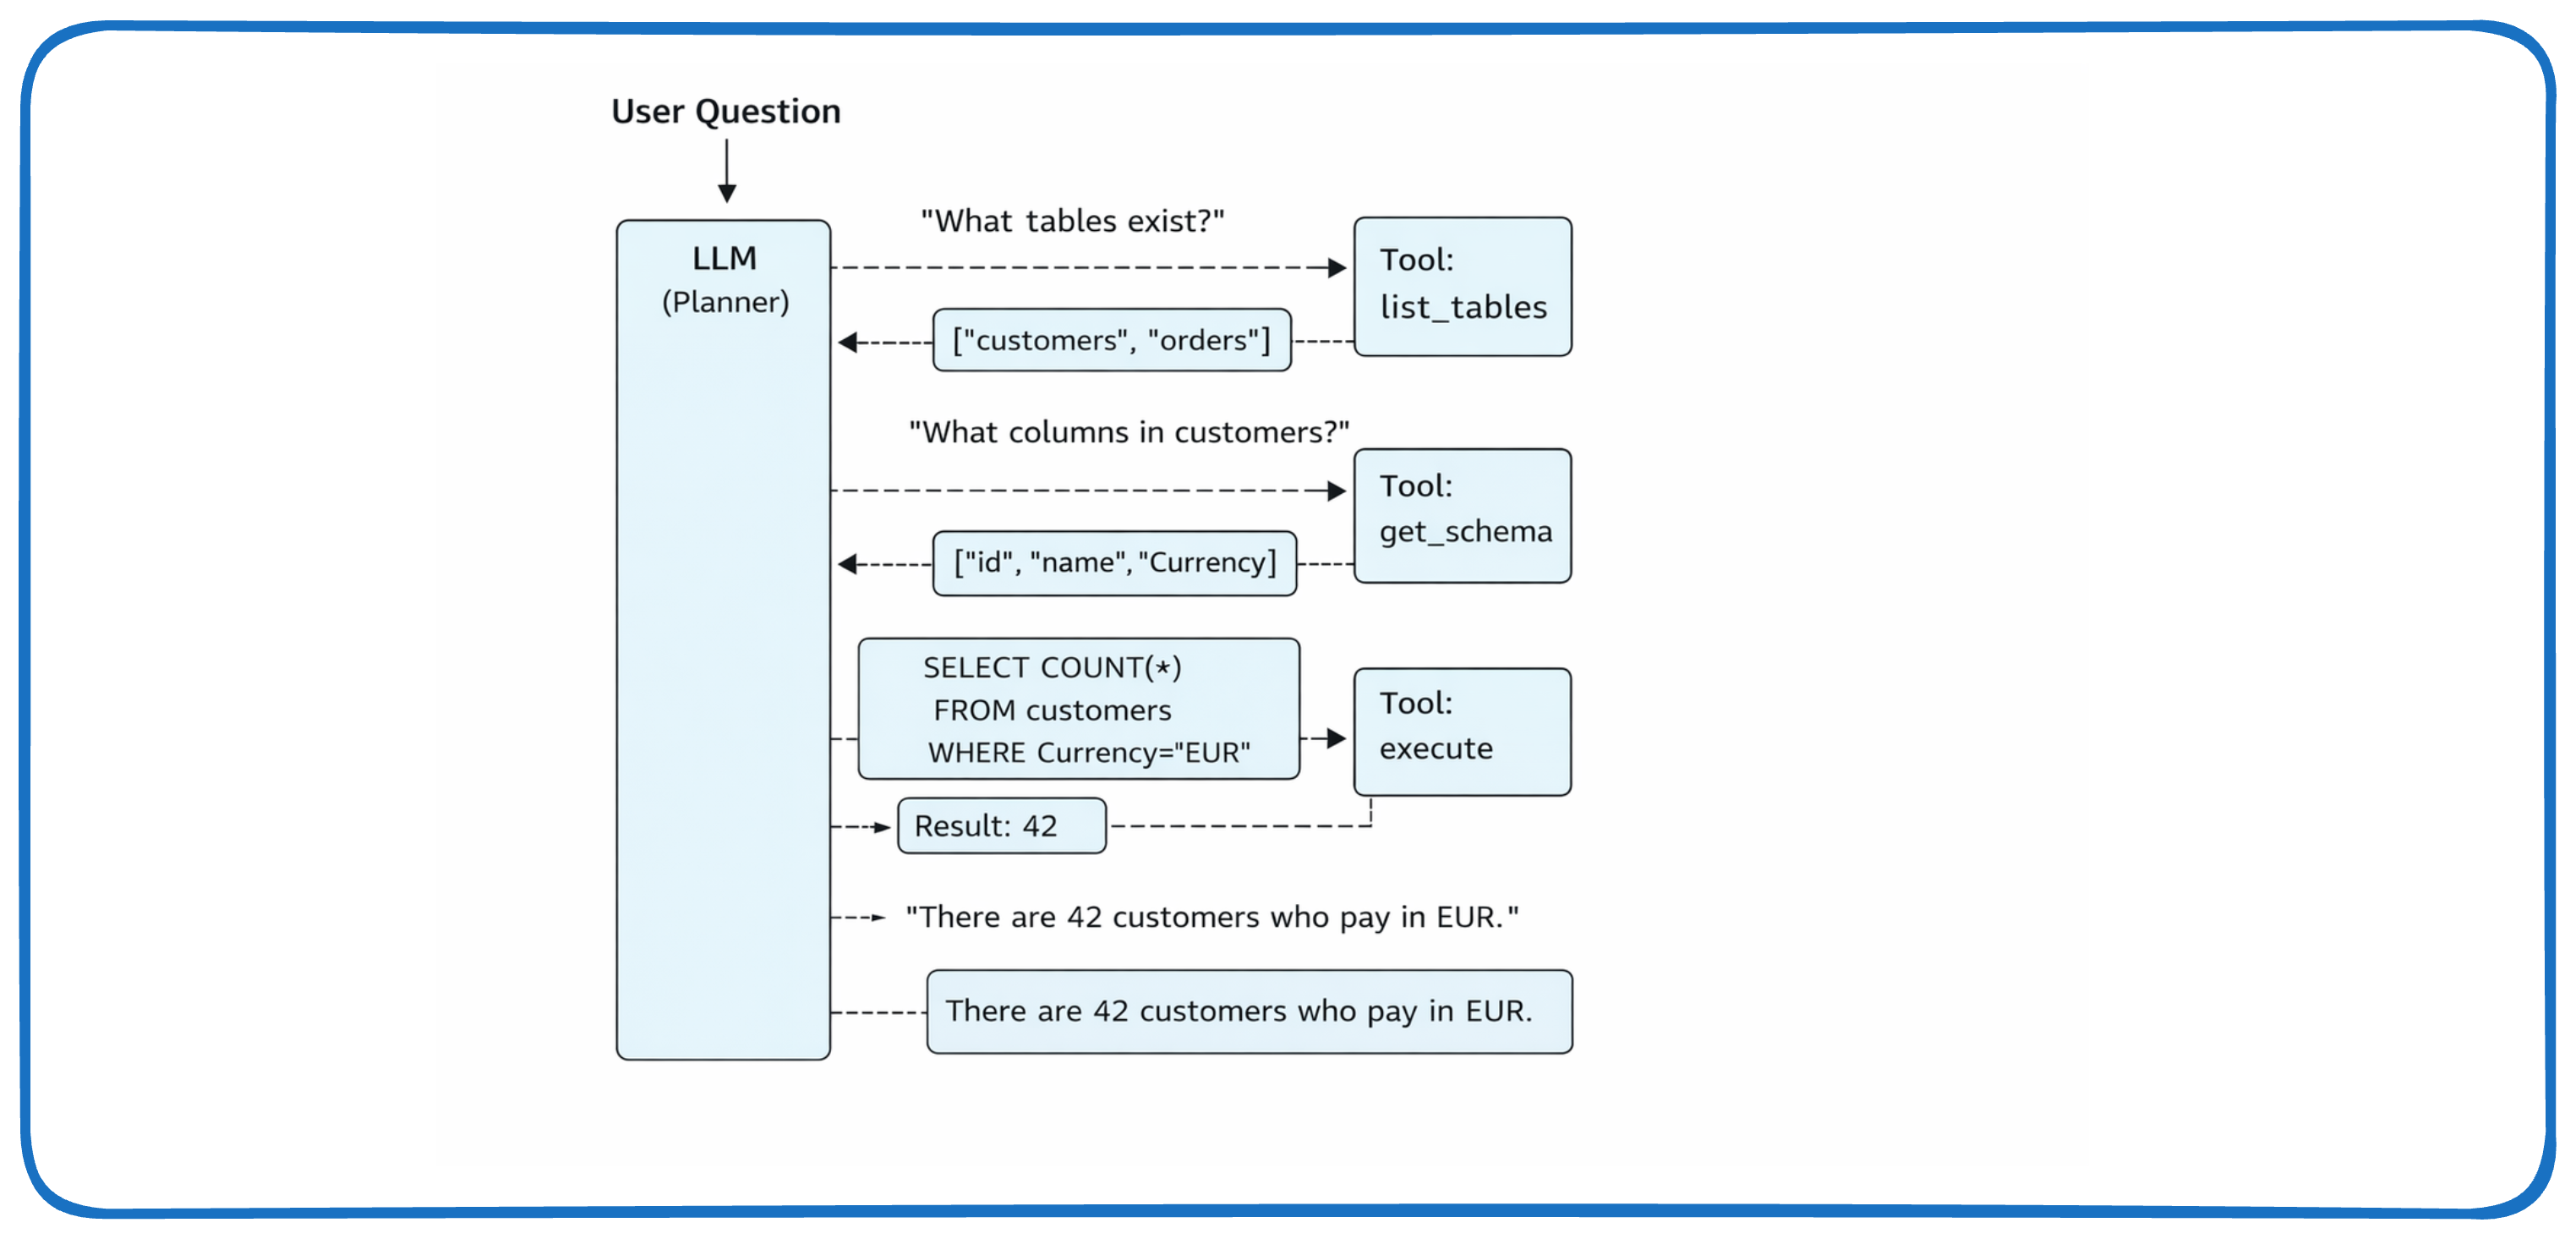

## CoT vs ReAct in Agent Context

| Aspect | Chain-of-Thought | ReAct |
|--------|-----------------|-------|
| **What it does** | Reasons through steps internally before answering | Alternates between reasoning and tool execution |
| **Tool usage** | None — pure reasoning | Core to the pattern — tools are called mid-thought |
| **Our agent** | Helps the LLM plan the SQL logic ("I need a CASE WHEN for ratios") | Drives the full loop: list tables → get schema → write query → execute |

Tools give an agent the ability to act beyond just generating text. As the slide describes, tools allow an agent to interact with the external world, manipulate data, connect with other systems, and orchestrate tasks. Without tools, an LLM is a brain in a jar — it can think and reason, but it can't do anything.

Function calling is the capability that connects LLMs to external tools in a structured way. Despite the name, the LLM does not execute the function itself. Instead, when a user sends a prompt, the model analyzes the input and determines whether a function would be appropriate for the task. If so, it generates a structured JSON object specifying which function to call and what parameters to pass — rather than generating a text response.

## Key Takeaways

1. **Tools are deterministic functions called by a non-deterministic agent** — The tool always does the same thing; the LLM decides *when* to call it.
2. **The LLM never executes the tool** — It outputs JSON saying "call this function with these args." Your application does the actual execution.
3. **Descriptions are the interface** — The LLM decides which tool to use based on the `description` field. Write them for an LLM audience, not a human developer.
4. **Not all LLMs support function calling** — Only models fine-tuned for tool use (GPT-4o, Gemini 2.0, Claude, etc.) can reliably trigger tools. Base models will ignore them.
5. **Three tools are enough** — `list_tables` → `get_table_schema` → `execute_sql` covers the entire Text2SQL workflow.

---
## 🧱 Foundation Complete

All components are loaded and verified:

| Component | Status | Variable / Function |
|---|---|---|
| Persona | ✅ | `persona`, `build_system_prompt()` |
| LLM Client | ✅ | `client` (OpenAI) |
| Database | ✅ | MySQL + BIRD + `employees` demo table |
| Tools | ✅ | `list_tables()`, `get_table_schema()`, `execute_sql()` |
| Tool Schema | ✅ | `tools_schema`, `tool_functions` |
| Planner | ✅ | `generate_plan()` |
| Agent Loop | ✅ | `run_agent()` |

Ready for iterative expansion (guardrails, evaluation, multi-agent, long-term memory, etc.).

 Core Components of an Agentic System
Five components recur across virtually every agentic architecture, regardless of framework or domain.

Planning is the system's ability to decompose a high-level goal into a sequence of actionable steps before executing any of them. In a Text2SQL agent, this means deciding: first list the available tables, then inspect the relevant schema, then construct the query, then execute it. The plan can be generated by the LLM itself (explicit chain-of-thought planning) or encoded in the orchestration logic (implicit planning through code). Explicit planning is more flexible; implicit planning is more predictable. Production systems typically use both — the developer hardcodes the coarse workflow stages, and the LLM plans within each stage.

Tool usage is what separates an agent from a chatbot. Tools are functions the LLM can invoke: database queries, API calls, file reads, code execution. The critical design concern is the interface between the LLM and the tool. Anthropic's engineering guidance emphasizes investing as much effort in the agent-computer interface (ACI) as developers typically invest in human-computer interfaces. This means writing precise tool descriptions, constraining parameter schemas, and providing usage examples — because the LLM's ability to use a tool correctly depends entirely on how well the tool is documented in the prompt.

Memory determines what the system knows across turns and across sessions. Short-term memory is the conversation history — the list of messages exchanged within a single run. Long-term memory is any persistence mechanism that carries information across runs: cached schemas, correction logs, user preferences. In agentic Text2SQL, short-term memory is the messages list that accumulates tool calls and results within a single question. Long-term memory is a store of past errors and corrections that informs future generation.

Reflection and feedback are the mechanisms through which the system evaluates its own output. Feedback can come from four sources: self-critique (the LLM evaluates its own generation), external tools (the database returns an error), validation checks (a schema validator confirms column names exist), and user input (the human says "that's not what I asked"). The value of feedback is proportional to its specificity. A binary "wrong" signal is almost useless. A structured critique that says "column dept does not exist in table employees; the correct column is department" is directly actionable.

Control logic is the glue. It determines what happens after each step: should the system retry? Route to a different tool? Ask the user for clarification? Terminate? Control logic is where engineering discipline matters most, because without it, agentic systems degrade into open-ended recursion. Every production agent needs explicit stopping conditions: a maximum iteration count, a confidence threshold, a success criterion. The system must be able to fail gracefully rather than loop indefinitely.

# Text to sql Project

https://github.com/subrata-samanta/text-to-sql-drgc-agent